In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from math import sqrt

In [2]:
df = pd.read_parquet("../data/compiled_dataset.parquet")

In [3]:
df.head()

,Covered_Recipient_NPI,YEAR,OTHER_PRESCRIPTIONS,ENTRESTO_PRESCRIPTIONS,ENTRESTO_PAYMENTS,OTHER_PAYMENTS,ALL_PRESCRIPTIONS
0,1003000126,2015,44,0,0.0,0.0,44
1,1003000126,2016,31,0,0.0,0.0,31
2,1003000126,2017,15,0,0.0,0.0,15
3,1003000126,2018,24,0,0.0,0.0,24
4,1003000126,2019,33,0,0.0,0.0,33


In [5]:
x = df[['ENTRESTO_PAYMENTS']]
y = df[['ENTRESTO_PRESCRIPTIONS']]

In [6]:
# Run OLS regression on payments vs. prescriptions
m, b = np.polyfit(x.squeeze(), y, 1)
y_fit = [m * k + b for k in x.values]
r2 = r2_score(y, y_fit)

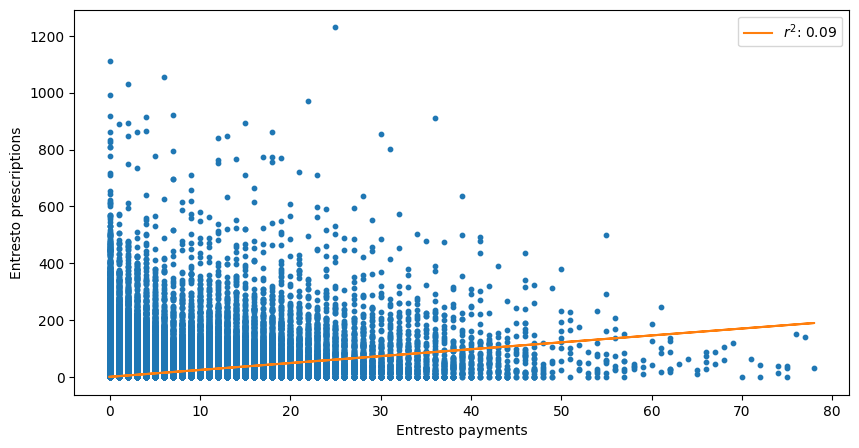

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x,y, s=10)
ax.plot(x, y_fit, color="tab:orange", label=f"$r^2$: {r2:.2f}")
ax.set(xlabel="Entresto payments", ylabel="Entresto prescriptions")
ax.legend(loc="upper right")
plt.show()

In [9]:
# Group payments and prescriptions by year
by_year = df.groupby('YEAR')[['ENTRESTO_PAYMENTS', 'ENTRESTO_PRESCRIPTIONS']].sum()
years = by_year.index

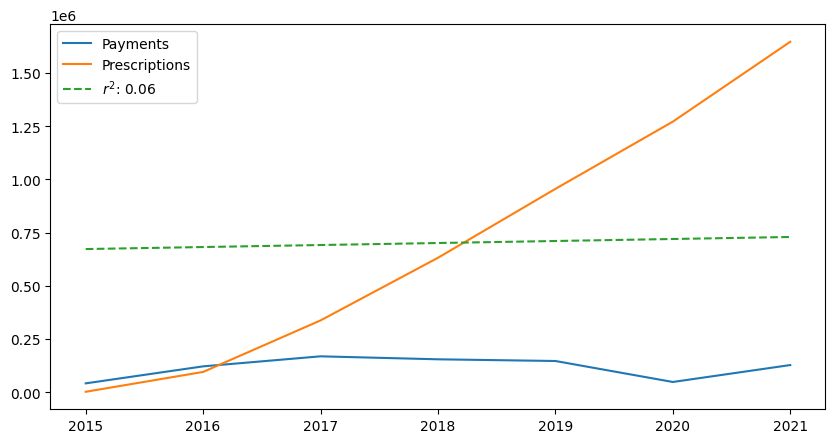

In [10]:
# Run OLS on the grouped data
x_yr = by_year['ENTRESTO_PAYMENTS']
y_yr = by_year['ENTRESTO_PRESCRIPTIONS']
m, b = np.polyfit(x_yr, y_yr, 1)

x_fit = np.linspace(x_yr.min(), x_yr.max(), 7)
y_fit = [m * k + b for k in x_fit]
r2 = r2_score(y_yr, y_fit)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years, by_year['ENTRESTO_PAYMENTS'], label='Payments')
ax.plot(years, by_year['ENTRESTO_PRESCRIPTIONS'], label='Prescriptions')
ax.plot(years, y_fit, label=f'$r^2$: {r2:.2f}', linestyle='dashed')
ax.legend()
plt.show()

In [31]:
# Run the multiple regression

# Add a small constant to account for 0s
df['log_payments'] = np.log(df['ENTRESTO_PAYMENTS'] + .0001)
df['log_prescriptions'] = np.log(df['ENTRESTO_PRESCRIPTIONS'] + .0001)

# Generate the dummy variables for year
dummy_df = pd.get_dummies(df, columns=['YEAR'], drop_first=True)
X = dummy_df[['log_payments','YEAR_2016','YEAR_2017','YEAR_2018','YEAR_2019','YEAR_2020','YEAR_2021']]

# Add the intercept term
X = np.column_stack([np.ones(X.shape[0]), X])
X = X.astype(np.float64)

y = df['log_prescriptions']

# Minimize the SSR
beta = np.linalg.inv(X.T @ X) @ X.T @ y
intercept = beta[0]
coefficients = beta[1:]

intercept, coefficients

(np.float64(-7.00105617001325),
 array([0.25609893, 0.00739959, 0.2064296 , 0.46520587, 0.73889793,
        1.12649303, 1.23194159]))